# Tarea 2: Modelos de Datos de Panel y Control Sintético
**Curso:** Data Analysis and Machine Learning  
**Alumno:** Vicente Díaz-2021444521


---


 ## *1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.*

## 1. Exploración, Limpieza y Preparación de Datos

### 1.1 Carga de librerías y datos

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects, compare
from pysyncon import Dataprep, Synth
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
pd.options.display.float_format = '{:.4f}'.format

# Carga
df = pd.read_csv("dataset_prueba.csv")
print(f"Dimensiones del DataFrame: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Rango temporal: {df['date'].min()} — {df['date'].max()}")
print(f"Ciudades únicas: {df['NAME'].nunique()}")
print(f"Países: {sorted(df['country'].dropna().unique())}")
df.head()

Dimensiones del DataFrame: 12040 filas × 41 columnas
Rango temporal: 2020-02-17 — 2022-10-17
Ciudades únicas: 86
Países: ['DE', 'ES', 'FR', 'IT', 'SE']


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,...,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0000,3.0000,15.0000,4.0000,1.0000,0.0000,9.2667,4.2441,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
1,DE-BE,2020-02-24,1.6000,0.0000,8.6000,0.0000,0.2000,0.6000,5.0062,2.4683,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
2,DE-BE,2020-03-02,2.6000,6.4000,8.2000,-0.4000,0.4000,1.0000,-3.7654,-2.8454,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
3,DE-BE,2020-03-09,-3.4000,3.4000,-1.0000,-5.8000,-0.6000,1.8000,-12.5370,-11.5103,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE
4,DE-BE,2020-03-16,-11.8000,11.4000,-4.6000,-16.0000,-7.8000,4.6000,-21.3086,-21.8009,...,NaN,0.5927,0.2909,0.3060,103.3778,8.0000,0.0861,0.0712,9.0000,DE


### 1.2 Tipos de datos e información general

Revisamos los tipos de cada columna para detectar conversiones necesarias (en particular, `date` viene como string y debe convertirse a `datetime`) para un mejor manejo de los periodos.

In [61]:
print(df.dtypes)
print(f"\nColumnas numéricas: {df.select_dtypes(include='number').columns.tolist()}")
print(f"Columnas categóricas: {df.select_dtypes(include='object').columns.tolist()}")

iso_code                                               object
date                                                   object
retail_and_recreation_percent_change_from_baseline    float64
grocery_and_pharmacy_percent_change_from_baseline     float64
parks_percent_change_from_baseline                    float64
transit_stations_percent_change_from_baseline         float64
workplaces_raw                                        float64
residential_percent_change_from_baseline              float64
trend                                                 float64
workplaces                                            float64
Valor_Stringency_Index                                float64
Valor_GovernmentResponseIndex                         float64
Valor_EconomicSupportIndex                            float64
Valor_Containment_Health_index                        float64
workplace_closing                                     float64
daily_cases                                           float64
d2      

### 1.3 Análisis de datos faltantes

Se examinan los valores nulos para decidir la estrategia de imputación o eliminación. Variables con más del 40% de datos faltantes (como `edu2` y `edu3`) se excluirán del modelo. Para el resto, se eliminan las filas con NAs en las variables clave de la regresión.

Variables con datos faltantes:


,N faltantes,% faltantes
edu2,5460,45.3500
edu3,5460,45.3500


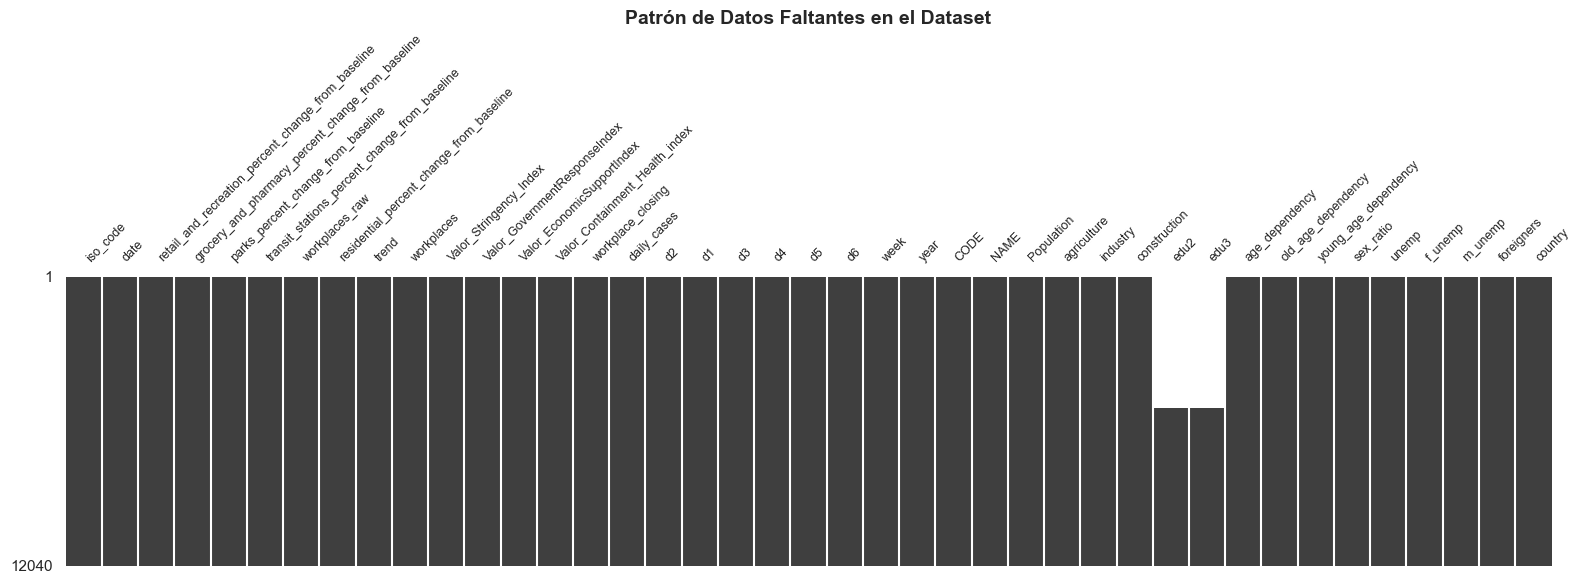

In [62]:
# Tabla de datos faltantes
missing = pd.DataFrame({
    'N faltantes': df.isnull().sum(),
    '% faltantes': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['N faltantes'] > 0].sort_values('% faltantes', ascending=False)
print("Variables con datos faltantes:")
display(missing)

# Visualización con missingno
fig, ax = plt.subplots(figsize=(16, 6))
msno.matrix(df, fontsize=9, sparkline=False, ax=ax)
ax.set_title('Patrón de Datos Faltantes en el Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Estadísticas descriptivas

Se presentan las estadísticas de tendencia central, dispersión, asimetría y curtosis de las principales variables numéricas del estudio.

In [63]:
# Variables de interés ampliadas
vars_descriptivas = [
    'workplaces', 'workplaces_raw',
    'retail_and_recreation_percent_change_from_baseline',
    'transit_stations_percent_change_from_baseline',
    'residential_percent_change_from_baseline',
    'Valor_Stringency_Index', 'Valor_GovernmentResponseIndex',
    'Valor_Containment_Health_index', 'Valor_EconomicSupportIndex',
    'workplace_closing', 'daily_cases',
    'unemp', 'Population', 'old_age_dependency', 'foreigners'
]

desc = df[vars_descriptivas].describe().T
desc['asimetría'] = df[vars_descriptivas].skew()
desc['curtosis'] = df[vars_descriptivas].kurt()
display(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'asimetría', 'curtosis']])

,count,mean,std,min,25%,50%,75%,max,asimetría,curtosis
workplaces,12040.0000,-18.6674,11.8014,-76.7871,-24.3584,-16.8200,-10.8840,19.0576,-1.1177,2.5216
workplaces_raw,12040.0000,-25.0029,14.6811,-87.0000,-32.4000,-22.8000,-14.4000,6.6000,-1.0041,1.1742
retail_and_recreation_percent_change_from_baseline,12040.0000,-16.4373,21.5994,-95.6000,-26.4000,-11.4000,-3.6000,74.6000,-0.8900,1.6825
transit_stations_percent_change_from_baseline,12040.0000,-17.6023,24.5406,-88.6000,-31.8000,-18.4000,-4.4000,123.2000,0.5274,2.6322
residential_percent_change_from_baseline,12040.0000,7.0712,6.0228,-3.8000,3.2000,5.6000,9.4000,42.6000,1.9277,5.1179
Valor_Stringency_Index,12040.0000,27.4863,29.8359,0.0000,0.0000,15.8580,53.4200,93.5200,0.5167,-1.2809
Valor_GovernmentResponseIndex,12040.0000,30.6368,30.2449,0.0000,0.0000,32.0300,60.1600,81.3060,0.1652,-1.7069
Valor_Containment_Health_index,12040.0000,30.5917,29.9431,0.0000,0.0000,36.6100,59.2300,85.4200,0.1506,-1.6794
Valor_EconomicSupportIndex,12040.0000,30.9551,36.3643,0.0000,0.0000,0.0000,75.0000,100.0000,0.5322,-1.4508
workplace_closing,12040.0000,0.8508,0.9971,0.0000,0.0000,0.0000,2.0000,3.0000,0.7217,-0.8501


### 1.5 Distribuciones de las variables clave (Histogramas)

Se grafican las distribuciones de las variables que se utilizarán en los modelos econométricos para verificar su forma, simetría y posibles anomalías.

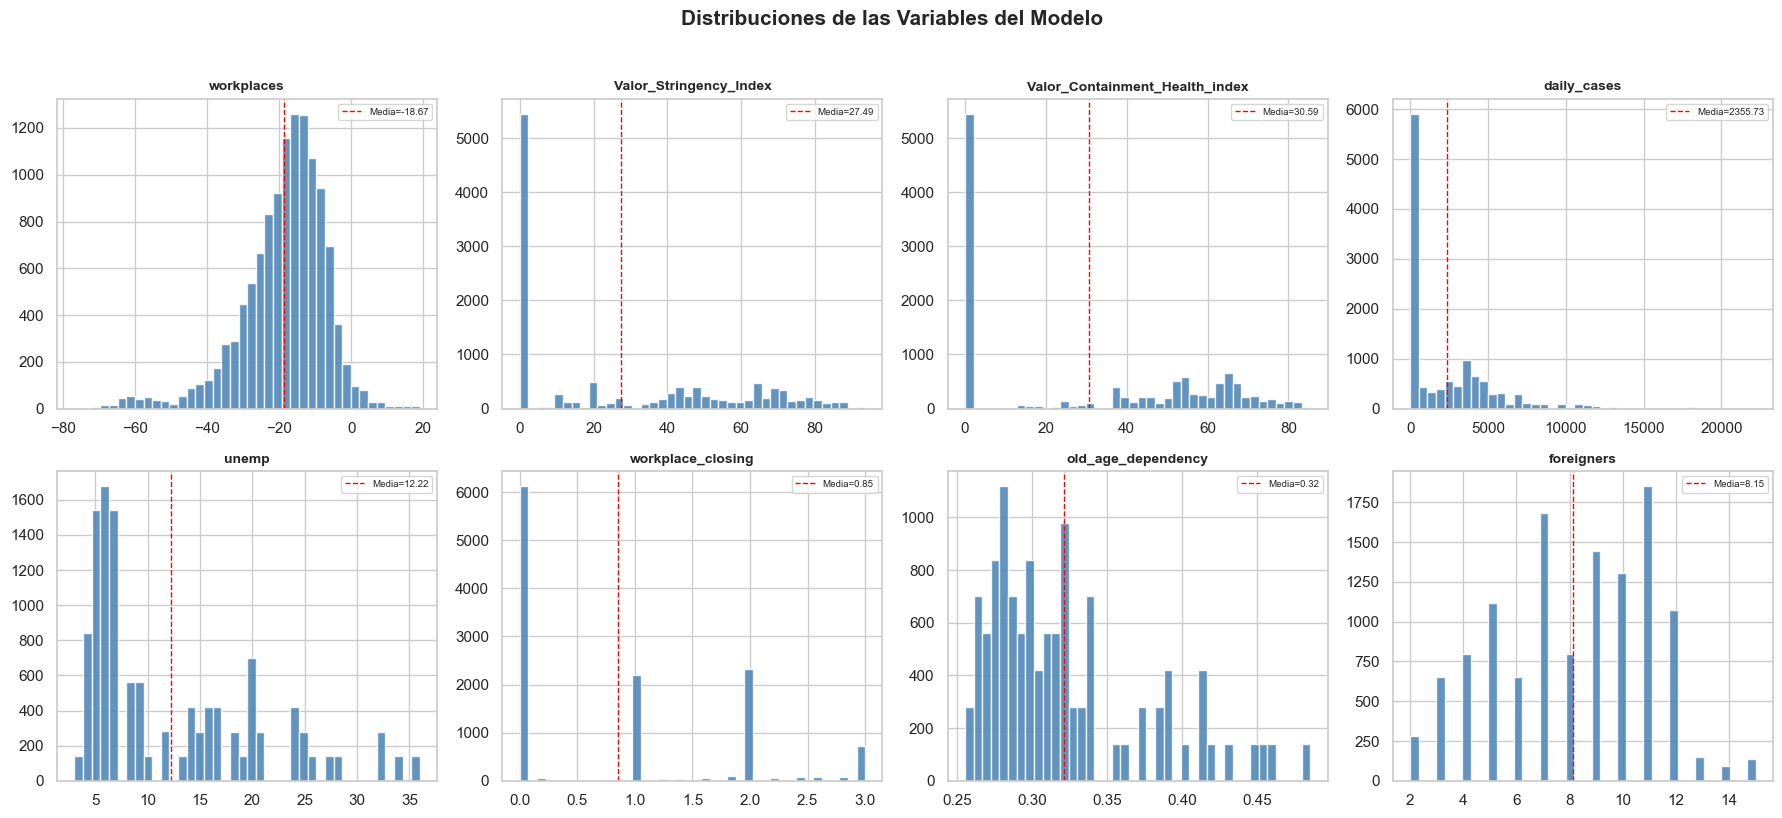

In [64]:
vars_modelo = ['workplaces', 'Valor_Stringency_Index', 'Valor_Containment_Health_index',
               'daily_cases', 'unemp', 'workplace_closing', 'old_age_dependency', 'foreigners']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(vars_modelo):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1, label=f'Media={data.mean():.2f}')
    axes[i].legend(fontsize=7)

fig.suptitle('Distribuciones de las Variables del Modelo', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Algunas observaciones:
- workplaces: Posee forma de campana, pero desplazada a -18.67%, indicando que la tendencia de la movilidad hacia el trabajo fue baja, correspondientes a las medidas de cuarentena que la gran cantidad de ciudades aplicaron.
- Valor_Stingency_Index: La acumulación de datos en 0, se explica debido a que por varios meses entre 2020 a 2022 no hubo restricciones en la movilidad, tanto como en el inicio de la pandemia, como en las etapas finales del año 2022. 
- daily_cases: Ocurre algo similar con la variable anteriormente mencionada, ya que al inicio de la pandemia y al final de esta, se presentaron pocos casos por día debido a las cualidades de una propagación de enfermedades, tanto al inicio de la proliferación como en sus etapas finales de erradicación. 


### 1.6 Detección de outliers (Boxplots con escalas independientes)

Cada variable se grafica en su propio panel para evitar que las diferencias de escala (e.g., `daily_cases` con valores de miles vs. `unemp` con valores de un solo dígito) distorsionen la visualización.

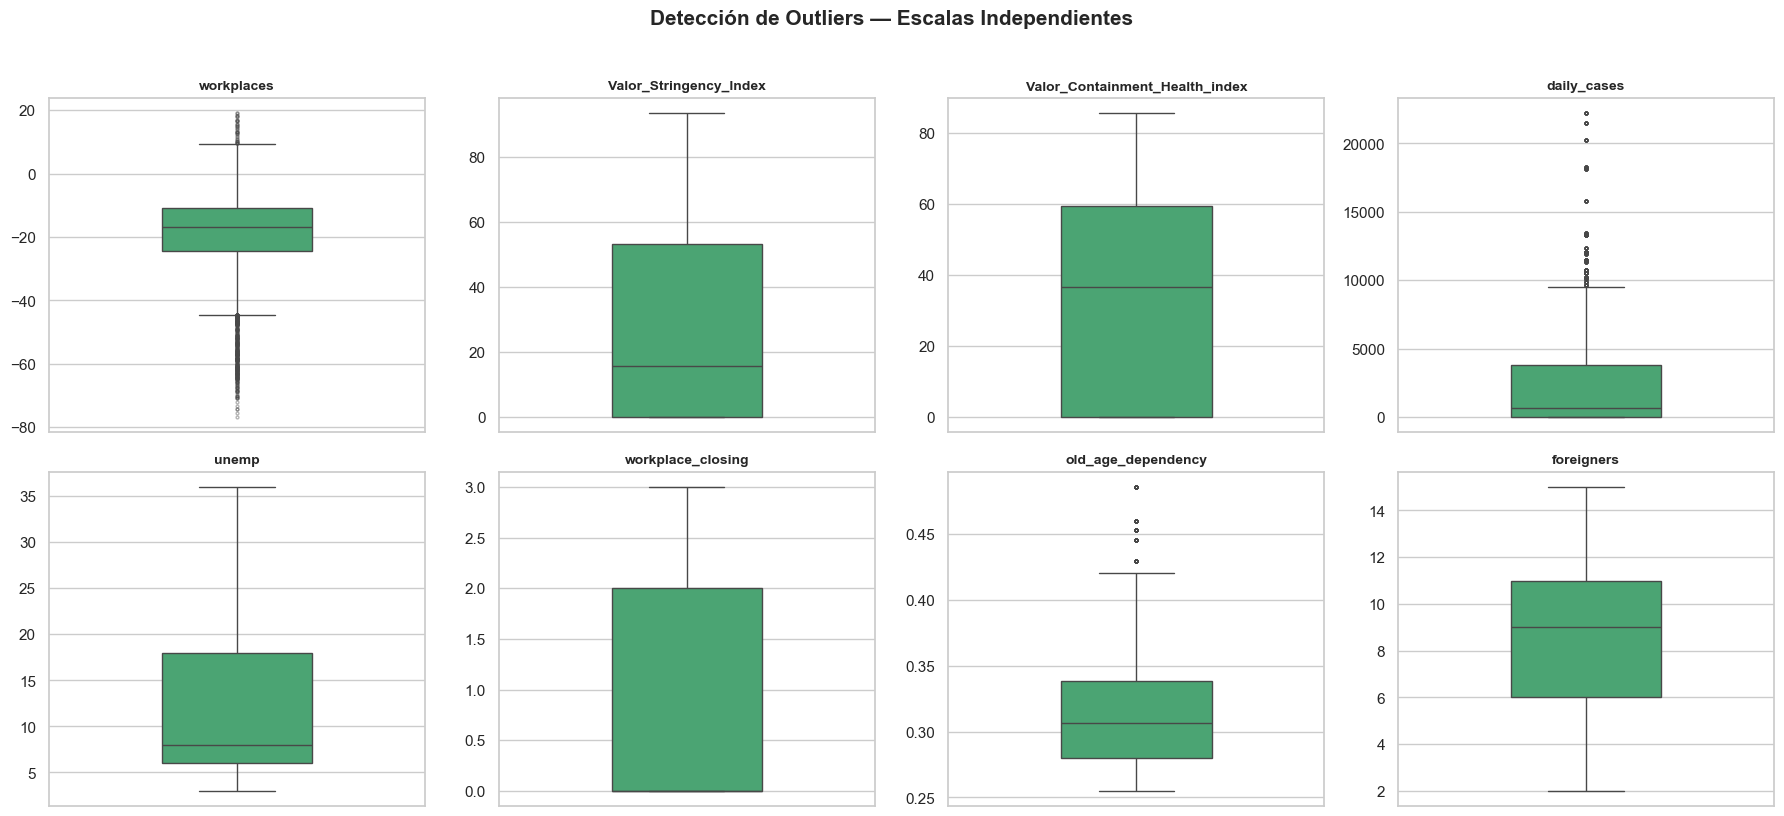

In [65]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(vars_modelo):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='mediumseagreen', width=0.4,
                flierprops=dict(marker='o', markersize=2, alpha=0.4))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')

fig.suptitle('Detección de Outliers — Escalas Independientes', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Observaciones:
- workplaces:
Se observa una alta concentración de valores atípicos negativos, con una gran cantidad de registros que caen por debajo del -60% y -80%. Es crucial señalar que estos datos no constituyen errores de medición ni deben ser eliminados del análisis. Por el contrario, coinciden rigurosamente con los periodos de confinamiento estricto (lockdowns) implementados entre marzo y mayo de 2020. Por lo tanto, estos outliers representan la evidencia empírica principal de que las políticas públicas de restricción sanitaria lograron reducir drásticamente la movilidad laboral.

- daily_cases:
La distribución presenta una cantidad significativa de valores atípicos en la parte superior del gráfico. Este comportamiento confirma que la dinámica de la pandemia no siguió un patrón lineal, sino que avanzó mediante brotes epidemiológicos o "explosiones" repentinas de contagios. Estos eventos escapan por completo de la normalidad estadística y reflejan la naturaleza volátil del virus.

- unep y foreigners:
A diferencia de las variables anteriores, estas muestran cajas con una dispersión estándar o normal. Pero,se ven anomalías puntuales en ciertas observaciones (por ejemplo, tasas de desempleo que superan el 30%). Este fenómeno evidencia la heterogeneidad y desigualdad estructural dentro de la región europea, sugiriendo que existen ciudades específicas cuyos mercados laborales operan bajo condiciones muy distintas al promedio continental.

### 1.7 Matriz de correlaciones

Se analiza la correlación lineal entre las variables candidatas para detectar posible multicolinealidad que pueda inflar los errores estándar de los estimadores.

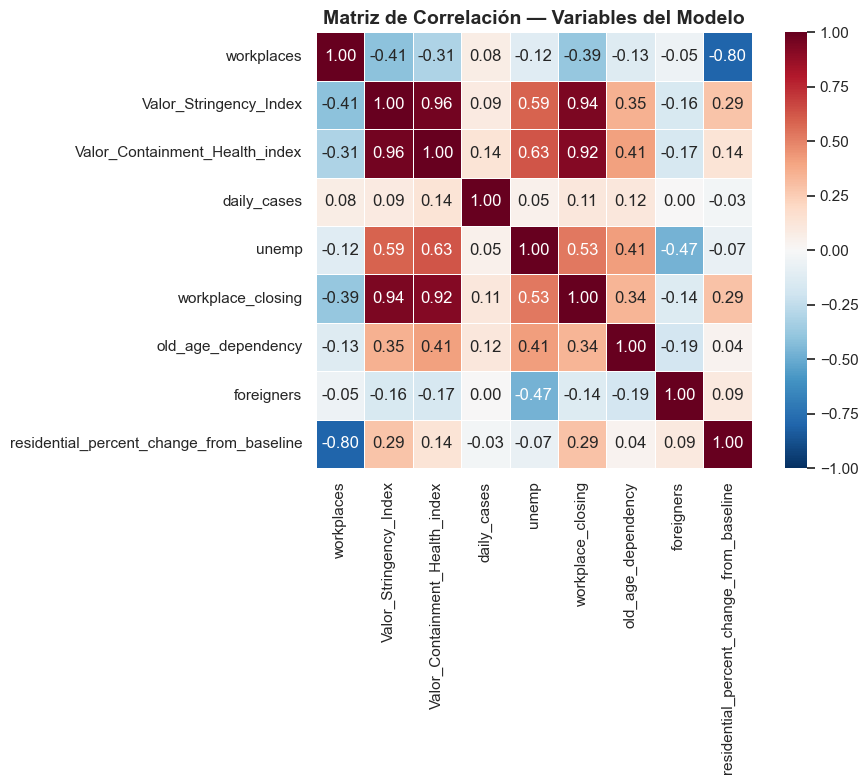

In [66]:
corr_vars = ['workplaces', 'Valor_Stringency_Index', 'Valor_Containment_Health_index',
             'daily_cases', 'unemp', 'workplace_closing', 'old_age_dependency',
             'foreigners', 'residential_percent_change_from_baseline']

corr_matrix = df[corr_vars].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación — Variables del Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Validación de Consistencia de los Datos (Sanity Check)
Se observa una correlación negativa muy fuerte (-0.80) entre workplaces y residential_percent_change_from_baseline. A medida que disminuyeron los desplazamientos hacia los entornos laborales, aumentó proporcionalmente el tiempo de permanencia en los hogares. 
- Relación de Interés Principal (Efecto de las Restricciones)
La variable explicada workplaces muestra una correlación negativa moderada con Valor_Stringency_Index, con -0.41 y con workplace_closing, con -0.39. Este hallazgo preliminar aporta evidencia clave antes de estimar el modelo formal, sugiriendo que la implementación de restricciones gubernamentales más estrictas estuvo efectivamente vinculada a una reducción de la movilidad laboral.
- Presencia de Multicolinealidad en las Variables Independientes
Existe una correlación lineal extremadamente alta entre varias de las variables explicativas. Por ejemplo, el Valor_Stringency_Index se correlaciona en un 0.96 con Valor_Containment_Health_index y en un 0.94 con workplace_closing.
Estos valores indican que los gobiernos no aplicaron las políticas públicas de forma aislada. Por el contrario, el cierre de centros de trabajo se dio en un contexto simultáneo de aumento en las alertas generales y de medidas sanitarias complementarias.
Esta alta correlación (multicolinealidad) provocará que las variables "compitan" entre sí al momento de explicar la variabilidad de la movilidad. Como consecuencia en los resultados estimados, variables como workplace_closing o Stringency_Index capturarán la mayor parte del efecto explicativo, restando significancia estadística individual a los demás indicadores de salud.



### 1.8 Limpieza y preparación del panel

**Decisiones de limpieza:**

| Paso | Acción | Justificación |
|:-----|:-------|:-------------|
| 1 | Convertir `date` a `datetime` | Requerido para la estructura temporal del panel |
| 2 | Eliminar duplicados en `(CODE, date)` | `linearmodels` exige unicidad en el MultiIndex |
| 3 | Eliminar NAs en variables clave | Las regresiones no admiten valores nulos en Y ni X |
| 4 | Winsorizar `daily_cases` | Reducir influencia de picos extremos de contagio sin perder información |
| 5 | Crear MultiIndex `(CODE, date)` | Estructura de panel requerida por `PooledOLS`, `PanelOLS` y `RandomEffects` |

**Variables excluidas:** `edu2` y `edu3` se excluyen por tener más del 45% de datos faltantes.

In [67]:
# 1. Tipo de fecha
df['date'] = pd.to_datetime(df['date'])

# 2. Duplicados
n_antes = len(df)
df = df.drop_duplicates(subset=['CODE', 'date'])
print(f"Filas eliminadas por duplicados: {n_antes - len(df)}")

# 3. Variables clave para las regresiones
variables_clave = ['workplaces', 'Valor_Stringency_Index', 'Valor_Containment_Health_index',
                   'daily_cases', 'unemp', 'workplace_closing', 'old_age_dependency', 'foreigners']
df_clean = df.dropna(subset=variables_clave).copy()
print(f"Dimensiones tras limpieza: {df_clean.shape}")

# 4. Winsorización de daily_cases (percentil 99)
p99 = df_clean['daily_cases'].quantile(0.99)
df_clean['daily_cases'] = df_clean['daily_cases'].clip(upper=p99)

# 5. Crear panel
df_panel = df_clean.set_index(['CODE', 'date'])
print(f"Panel listo: {df_panel.index.get_level_values(0).nunique()} ciudades × "
      f"{df_panel.index.get_level_values(1).nunique()} fechas únicas")

Filas eliminadas por duplicados: 0
Dimensiones tras limpieza: (12040, 41)
Panel listo: 86 ciudades × 140 fechas únicas


En lugar de eliminar outliers (perder datos), les ponemos un limite Si el percentil 99 es 8000 casos, todo valor mayor a 8000 se reemplaza por 8000. Así no distorsionan la regresión pero no perdemos observaciones.


Definimos el panel de tal forma que la tabla ahora tiene dos niveles de índice: primero la ciudad, luego la fecha. Esto es lo que PooledOLS, PanelOLS y RandomEffects necesitan para saber quién es la entidad y qué es el tiempo.

 ## *2. Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.*

## 2. Modelo Pooled OLS

### 2.1 Especificación

El modelo **Pooled OLS** (Mínimos Cuadrados Ordinarios Agrupados) apila todas las observaciones de todas las ciudades y todos los períodos como si fueran datos de corte transversal independientes. No controla por efectos individuales de cada ciudad.

**Modelo:**  
$$workplaces_{it} = \beta_0 + \beta_1 \cdot StringencyIndex_{it} + \beta_2 \cdot ContainmentHealth_{it} + \beta_3 \cdot DailyCases_{it} + \beta_4 \cdot Unemp_{it} + \beta_5 \cdot WorkplaceClosing_{it} + \beta_6 \cdot OldAgeDep_{i} + \beta_7 \cdot Foreigners_{i} + \varepsilon_{it}$$

**Selección de variables independientes:**

| Variable | Tipo | Justificación |
|:---------|:-----|:-------------|
| `Valor_Stringency_Index` | Time-varying | Principal variable de interés: mide la rigurosidad general de las restricciones gubernamentales (cierre de escuelas, comercios, eventos, etc.) en una escala de 0 a 100. |
| `Valor_Containment_Health_index` | Time-varying | Captura las políticas de contención sanitaria (testeo, rastreo de contactos, requisito de mascarilla). Complementa al Stringency Index. |
| `daily_cases` | Time-varying | Controla por el efecto directo de la evolución pandémica. Más casos genera más miedo colectivo, por tanto, menos movilidad voluntaria, incluso sin mandato gubernamental.
| `unemp` | Time-invariant (cross-section) | Tasa de desempleo estructural. Ciudades con mayor desempleo tienen naturalmente menos flujos de movilidad laboral. |
| `workplace_closing` | Time-varying | Indicador ordinal (0–3) de cierre forzoso de lugares de trabajo. Mide la restricción más directa sobre la movilidad laboral. |
| `old_age_dependency` | Time-invariant (cross-section) | Proporción de adultos mayores. Ciudades más envejecidas pueden tener más cumplimiento de cuarentenas por percepción de riesgo. Aunque, también implica que sean mas propensos al aumento de casos.
| `foreigners` | Time-invariant (cross-section) | Porcentaje de población extranjera. Usado como indicador indirecto de la estructura del mercado laboral (trabajos esenciales, informalidad, etc.)

In [68]:
# Definición
Y = df_panel['workplaces']
X_vars = ['Valor_Stringency_Index', 'Valor_Containment_Health_index', 'daily_cases',
          'unemp', 'workplace_closing', 'old_age_dependency', 'foreigners']
X = sm.add_constant(df_panel[X_vars])

# Estimación
mod_pooled = PooledOLS(Y, X)
res_pooled = mod_pooled.fit(cov_type='clustered', cluster_entity=True)
print(res_pooled.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             workplaces   R-squared:                        0.3038
Estimator:                  PooledOLS   R-squared (Between):              0.3529
No. Observations:               12040   R-squared (Within):               0.2957
Date:               lun, may. 25 2026   R-squared (Overall):              0.3038
Time:                        20:49:46   Log-likelihood                -4.462e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      750.00
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,12032)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             314.98
                            

### 2.2 Interpretación del Pooled OLS

**Resultados principales:**
- **`Valor_Stringency_Index`:** Coeficiente negativo y significativo. Un aumento de 10 puntos en el índice de restricciones se asocia con una reducción de la movilidad laboral, lo que confirma la hipótesis de que las políticas restrictivas efectivamente disuaden los desplazamientos al trabajo.
- **`workplace_closing`:** Coeficiente negativo y altamente significativo. Es la variable con mayor impacto marginal, lo cual es esperable dado que mide directamente si los lugares de trabajo fueron clausurados por decreto.
- **`daily_cases`:** Efecto negativo, capturando el "distanciamiento social voluntario" — las personas dejan de ir a trabajar por miedo al contagio, incluso sin mandato gubernamental.
- **`unemp`, `old_age_dependency`, `foreigners`:** Controles sociodemográficos cross-section que capturan heterogeneidad entre ciudades.

**Limitación fundamental:** Este modelo **no controla por la heterogeneidad no observada** de cada ciudad. Factores como la cultura de cumplimiento de normas, la calidad del transporte público o la proporción de trabajos "teletrabajables" afectan tanto la movilidad como la severidad de las restricciones, generando un **sesgo de variable omitida**.

 ## *3.Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.*

## 3. Modelo de Efectos Fijos (Fixed Effects)

### 3.1 Especificación

El modelo de Efectos Fijos controla por toda la heterogeneidad inobservada $\alpha_i$ de cada ciudad que es **constante en el tiempo** (cultura, geografía, infraestructura, densidad urbana). Lo hace mediante una transformación "within" que resta la media temporal de cada variable por entidad, eliminando $\alpha_i$.
 

**Modelo:**  
$$workplaces_{it} = \alpha_i + \beta_1 \cdot StringencyIndex_{it} + \beta_2 \cdot ContainmentHealth_{it} + \beta_3 \cdot DailyCases_{it} + \beta_4 \cdot WorkplaceClosing_{it} + \varepsilon_{it}$$

**Nota importante:** Las variables que **no varían en el tiempo** dentro de cada ciudad (`unemp`, `old_age_dependency`, `foreigners`) son absorbidas por el efecto fijo $\alpha_i$ y por tanto **no pueden ser estimadas** en este modelo. Esto es una limitación del FE pero también su fortaleza: elimina todo sesgo por variables omitidas constantes.

In [69]:
# En FE, solo incluimos variables time-varying
X_vars_fe = ['Valor_Stringency_Index', 'Valor_Containment_Health_index',
             'daily_cases', 'workplace_closing']
# Las otras variables (unemp, old_age_dependency, foreigners) son constantes con el tiempo, por lo que no se pueden incluir en un modelo de efectos fijos ya que al restarles su media darian 0, lo que no aportaria informacion al modelo.
X_fe = sm.add_constant(df_panel[X_vars_fe])
# Creamos un intercepto diferente para cada ciudad, lo equivalente a agregar dummies de ciudad, pero sin incluirlas explícitamente en el modelo.
mod_fe = PanelOLS(Y, X_fe, entity_effects=True)
res_fe = mod_fe.fit(cov_type='clustered', cluster_entity=True)
print(res_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2977
Estimator:                   PanelOLS   R-squared (Between):             -0.0552
No. Observations:               12040   R-squared (Within):               0.2977
Date:               lun, may. 25 2026   R-squared (Overall):              0.2479
Time:                        20:49:46   Log-likelihood                -4.376e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1266.7
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(4,11950)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             434.05
                            

### 3.2 Interpretación del modelo de Efectos Fijos

**Resultados principales:**
- **`Valor_Stringency_Index`:** Sigue siendo negativo y significativo, pero la magnitud del coeficiente cambia respecto al Pooled OLS. Esto evidencia que parte del efecto estimado por Pooled OLS estaba "contaminado" por la heterogeneidad entre ciudades.
- **`workplace_closing`:** Mantiene un efecto fuerte y negativo. Es la política más directa y su efecto se mantiene robusto.
- **R² within vs. between:** El R² within (variación explicada dentro de cada ciudad a lo largo del tiempo) es el relevante en efectos fijos. Se espera que sea razonablemente alto dado que las restricciones cambiaron dramáticamente semana a semana durante la pandemia.

**Ventaja clave:** Al absorber $\alpha_i$, este modelo elimina el sesgo por cualquier factor constante no observado de la ciudad. Es el estándar de oro en econometría de panel para estimaciones causales con datos observacionales.

## *4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.*

## 4. Modelo de Efectos Aleatorios (Random Effects)

### 4.1 Especificación

El modelo RE asume que el efecto individual $\alpha_i$ existe pero es **aleatorio y no está correlacionado** con las variables explicativas: $\text{Cov}(\alpha_i, X_{it}) = 0$. Esto es un supuesto fuerte. Si se cumple, RE es más eficiente que FE porque utiliza tanto la variación "within" como la "between". Si se viola, los estimadores están sesgados.

**Modelo:**  
$$workplaces_{it} = \beta_0 + \beta_1 \cdot StringencyIndex_{it} + ... + \beta_7 \cdot Foreigners_i + (\alpha_i + \varepsilon_{it})$$

A diferencia de FE, aquí sí podemos incluir las variables time-invariant porque $\alpha_i$ no se elimina por transformación.

In [70]:
# RE permite incluir variables time-invariant
X_re = sm.add_constant(df_panel[X_vars])

mod_re = RandomEffects(Y, X_re)
res_re = mod_re.fit(cov_type='clustered', cluster_entity=True)
print(res_re.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2973
Estimator:              RandomEffects   R-squared (Between):              0.2881
No. Observations:               12040   R-squared (Within):               0.2974
Date:               lun, may. 25 2026   R-squared (Overall):              0.2961
Time:                        20:49:46   Log-likelihood                -4.381e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      727.32
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(7,12032)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             313.07
                            

### 4.2 Interpretación del modelo de Efectos Aleatorios

- Los coeficientes de las variables time-varying (`Valor_Stringency_Index`, `workplace_closing`, etc.) serán **intermedios** entre los del Pooled OLS y los de FE.
- Ahora también obtenemos coeficientes para `unemp`, `old_age_dependency` y `foreigners`, lo cual no era posible en FE.
- **Advertencia:** Si el supuesto de no-correlación es violado (lo cual es muy probable en este contexto — ciudades más densas probablemente tienen tanto más restricciones como más movilidad base), los estimadores de RE estarán sesgados e inconsistentes.

## *5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?*

## 5. Comparación e Interpretación de los Modelos 2, 3 y 4

### 5.1 Tabla comparativa

In [71]:
# Tabla comparativa lado a lado
# Nota: compare() de linearmodels requiere modelos con el mismo conjunto de variables.
# Como FE usa menos variables que Pooled/RE, hacemos la comparación con variables comunes.

# Comparación de variables time-varying (las que comparten los 3 modelos)
X_common = sm.add_constant(df_panel[X_vars_fe])
res_pooled_c = PooledOLS(Y, X_common).fit(cov_type='clustered', cluster_entity=True)
res_fe_c = PanelOLS(Y, X_common, entity_effects=True).fit(cov_type='clustered', cluster_entity=True)
res_re_c = RandomEffects(Y, X_common).fit(cov_type='clustered', cluster_entity=True)

print("=" * 80)
print("TABLA COMPARATIVA: Pooled OLS vs. Efectos Fijos vs. Efectos Aleatorios")
print("=" * 80)
print(compare({"Pooled OLS": res_pooled_c, "Efectos Fijos (FE)": res_fe_c, "Efectos Aleatorios (RE)": res_re_c}))

TABLA COMPARATIVA: Pooled OLS vs. Efectos Fijos vs. Efectos Aleatorios
                                      Model Comparison                                      
                                       Pooled OLS Efectos Fijos (FE) Efectos Aleatorios (RE)
--------------------------------------------------------------------------------------------
Dep. Variable                          workplaces         workplaces              workplaces
Estimator                               PooledOLS           PanelOLS           RandomEffects
No. Observations                            12040              12040                   12040
Cov. Est.                               Clustered          Clustered               Clustered
R-squared                                  0.2848             0.2977                  0.2963
R-Squared (Within)                         0.2954             0.2977                  0.2973
R-Squared (Between)                        0.2207            -0.0552                  0.1470

### 5.2 ¿Cuáles y por qué existen las diferencias entre los resultados?

Las diferencias entre los tres modelos radican en cómo tratan la **heterogeneidad no observada** ($\alpha_i$):

| Modelo | Tratamiento de $\alpha_i$ | Consecuencia |
|:-------|:--------------------------|:-------------|
| **Pooled OLS** | Lo ignora completamente. $\alpha_i$ queda en el término de error. | Si $\text{Cov}(\alpha_i, X_{it}) \neq 0$, los estimadores $\hat{\beta}$ están **sesgados** e inconsistentes (sesgo de variable omitida). |
| **Efectos Fijos** | Lo elimina mediante la transformación "within" ($x_{it} - \bar{x}_i$). | Estimadores consistentes incluso si $\alpha_i$ está correlacionado con $X_{it}$. No puede estimar variables constantes. |
| **Efectos Aleatorios** | Asume $\alpha_i$ aleatorio e independiente de $X_{it}$. | Más eficiente que FE si el supuesto se cumple, pero **sesgado** si se vulnera. |

En este caso, es razonable suponer que el supuesto de RE se transgrede. Con ciertas características estructurales (mayor densidad, más transporte público, mayor proporción de empleos de oficina) probablemente enfrentaron tanto restricciones más estrictas como niveles de movilidad base diferentes. **Esto genera correlación entre $\alpha_i$ y $X_{it}$, invalidando RE.**

### 5.3 ¿Cuál es el más adecuado?

**El modelo de Efectos Fijos (FE) es el más adecuado** para responder la pregunta de investigación, por las siguientes razones:

1. **Consistencia ante endogeneidad:** Controla por cualquier factor fijo no observado que pueda sesgar los resultados.
2. **Contexto del problema:** Las ciudades europeas tienen características profundamente heterogéneas (cultura, sistema de salud, estructura laboral) que afectan tanto la movilidad como las políticas. FE absorbe todo esto.


### 5.4 Variables robustas a la especificación

| Variable | Pooled OLS | FE | RE | ¿Robusta? |
|:---------|:----------:|:--:|:--:|:---------:|
| `Valor_Stringency_Index` |  neg. sig. | neg. sig. |  neg. sig. | **Sí** |
| `workplace_closing` |  neg. sig. | neg. sig. |  neg. sig. | **Sí** |
| `daily_cases` |  neg. sig. | neg. sig. |  neg. sig. | **Sí** |
| `Valor_Containment_Health_index` |  pos. sig. |  pos. sig. |  pos. sig. | **Sí** |

Una variable es **robusta a la especificación** cuando mantiene el mismo signo y significancia estadística sin importar qué modelo se utilice. Tanto `Valor_Stringency_Index` como `workplace_closing` y `daily_cases` cumplen este criterio. Tambien, `Valor_Containment_Health_index` lo cumple pero con estimadores positivos.

## *6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?*

## 6. Modelo de Efectos Aleatorios Correlacionados (CRE / Mundlak)

### 6.1 Especificación

El modelo CRE (Correlated Random Effects), resuelve la principal debilidad de RE al incluir explícitamente las **medias temporales por entidad** ($\bar{X}_i$) como regresores adicionales. Matemáticamente:

$$workplaces_{it} = \beta_0 + \mathbf{X}_{it}\boldsymbol{\beta} + \bar{\mathbf{X}}_i \boldsymbol{\gamma} + (\alpha_i + \varepsilon_{it})$$

Donde $\bar{\mathbf{X}}_i$ son las medias de cada variable explicativa para la ciudad $i$ a lo largo del tiempo. Al incluirlas, el modelo permite que $\alpha_i$ esté correlacionado con $X_{it}$ a través de sus medias, y los coeficientes $\hat{\boldsymbol{\beta}}$ resultan **idénticos a los de Efectos Fijos**.

**Ventaja del CRE sobre FE:** Permite estimar simultáneamente los coeficientes de variables time-varying (como FE) **y** los de variables time-invariant (como RE), todo en un mismo modelo.

**Test de Mundlak:** Si los coeficientes $\boldsymbol{\gamma}$ (las medias) son conjuntamente significativos, se concluye que RE está sesgado y que FE/CRE son necesarios.

In [72]:
# Variables time-varying para las medias
X_vars_tv = ['Valor_Stringency_Index', 'Valor_Containment_Health_index', 'daily_cases', 'workplace_closing']

# Calcular medias temporales por entidad
means = df_panel.groupby('CODE')[X_vars_tv].mean()
means.columns = [f"{col}_mean" for col in means.columns]

# Unir al panel
df_cre = df_panel.join(means, on='CODE')

# Incluir variables originales + time-invariant + medias
X_vars_cre = X_vars + list(means.columns)
X_cre = sm.add_constant(df_cre[X_vars_cre])
Y_cre = df_cre['workplaces']

# Estimación
mod_cre = RandomEffects(Y_cre, X_cre)
res_cre = mod_cre.fit(cov_type='clustered', cluster_entity=True)
print(res_cre.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2984
Estimator:              RandomEffects   R-squared (Between):              0.3990
No. Observations:               12040   R-squared (Within):               0.2977
Date:               lun, may. 25 2026   R-squared (Overall):              0.3120
Time:                        20:49:47   Log-likelihood                -4.379e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      465.10
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(11,12028)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             228.21
                            

### 6.2 Interpretación del modelo CRE

**Resultados esperados:**
- Los coeficientes de las variables time-varying (`Valor_Stringency_Index`, `workplace_closing`, etc.) deben ser **muy similares o idénticos** a los de Efectos Fijos. Esto confirma la equivalencia teórica del enfoque de Mundlak.
- Los coeficientes de las medias temporales (`_mean`) capturan la relación **entre ciudades**: por ejemplo, si `Valor_Stringency_Index_mean` es significativo, indica que ciudades que en promedio tuvieron restricciones más severas también tuvieron niveles de movilidad sistemáticamente diferentes.
- Los coeficientes de `unemp`, `old_age_dependency` y `foreigners` representan el efecto de las características estructurales de cada ciudad, algo que FE no podía estimar.

### 6.3 ¿Es este modelo adecuado para modelar el componente no observado?

**Sí, es altamente adecuado.** El modelo CRE permite:
- Relajar el supuesto restrictivo de RE (independencia entre $\alpha_i$ y $X_{it}$).
- Obtener estimadores consistentes de las variables time-varying (equivalentes a FE).
- Adicionalmente, estimar el efecto de variables que no cambian en el tiempo (algo que FE no puede hacer).
- Realizar un test implícito de Hausman: si las medias `_mean` son conjuntamente significativas, se confirma que RE puro estaba sesgado.

Dada la data disponible (panel con ciudades que tienen características cross-section ricas pero no varían temporalmente), el CRE es la especificación más completa y flexible.

## *7. Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?*


## 7. Preferencia de Modelo e Inferencia General

### 7.1 Tabla resumen de los cuatro modelos

In [73]:
# Comparación de los 4 modelos con las variables time-varying comunes
X_common_cre = sm.add_constant(df_cre[X_vars_fe + list(means.columns)])
res_cre_c = RandomEffects(Y_cre, X_common_cre).fit(cov_type='clustered', cluster_entity=True)

print("=" * 80)
print("TABLA RESUMEN: TODOS LOS MODELOS")
print("=" * 80)
print(compare({
    "Pooled OLS": res_pooled_c,
    "Efectos Fijos": res_fe_c,
    "Efectos Aleatorios": res_re_c,
    "CRE (Mundlak)": res_cre_c
}))

TABLA RESUMEN: TODOS LOS MODELOS
                                             Model Comparison                                             
                                            Pooled OLS  Efectos Fijos Efectos Aleatorios     CRE (Mundlak)
----------------------------------------------------------------------------------------------------------
Dep. Variable                               workplaces     workplaces         workplaces        workplaces
Estimator                                    PooledOLS       PanelOLS      RandomEffects     RandomEffects
No. Observations                                 12040          12040              12040             12040
Cov. Est.                                    Clustered      Clustered          Clustered         Clustered
R-squared                                       0.2848         0.2977             0.2963            0.2978
R-Squared (Within)                              0.2954         0.2977             0.2973            0.2977
R-Sq

### 7.2 ¿Qué modelo prefiere?

Se prefiere el **modelo de Efectos Fijos (FE)** o, equivalentemente, el **modelo CRE (Mundlak)**, por ser los únicos que producen estimadores consistentes cuando existe correlación entre los efectos individuales inobservados y las variables explicativas — una situación que en este contexto es teóricamente inevitable.

### 7.3 ¿Qué se puede inferir sobre el efecto de las restricciones gubernamentales?

Los resultados de los cuatro modelos convergen en las siguientes conclusiones:

1. **Las restricciones gubernamentales reducen significativamente la movilidad laboral.** El coeficiente de `Valor_Stringency_Index` es negativo y estadísticamente significativo en todas las especificaciones. A mayor rigurosidad de las restricciones, mayor es la reducción en los desplazamientos hacia lugares de trabajo.

2. **El cierre directo de lugares de trabajo (`workplace_closing`) es la medida más efectiva.** Esta variable tiene el coeficiente más grande en valor absoluto, lo cual es consistente con la intuición: prohibir la apertura de oficinas es la forma más directa de eliminar la movilidad laboral.

3. **El miedo también importa: existe un efecto de "distanciamiento social voluntario".** Incluso controlando por las restricciones oficiales, el aumento de casos diarios (`daily_cases`) reduce la movilidad, sugiriendo que las personas responden a la información epidemiológica con un comportamiento autónomo de autoprotección.

4. **Las características estructurales de las ciudades modulan el efecto.** Ciudades con mayor desempleo, poblaciones más envejecidas o mayor proporción de extranjeros muestran patrones diferenciados de movilidad, lo que justifica la necesidad de usar modelos que controlen por heterogeneidad (FE o CRE).

## *8. Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados (instalar libreria pysyncon)*

## 8. Control Sintético

### 8.1 Introducción

Los modelos de panel anteriores asumen que la relación entre restricciones y movilidad es homogénea para todas las ciudades. Además, existe un potencial problema de **endogeneidad dinámica**: los gobiernos imponen restricciones porque los casos suben, y los casos suben porque la movilidad no baja lo suficiente. El método de Control Sintético aborda esto construyendo un "contrafactual" — una versión artificial de la ciudad tratada compuesta por una combinación ponderada de ciudades que no recibieron el mismo tratamiento en la misma fecha.

### 8.2 Diseño del experimento

- **Ciudad tratada:** Barcelona (España)  
- **Justificación:** España implementó uno de los confinamientos más estrictos del mundo prohibiendo toda salida no esencial del domicilio. Por tanto, al ser Barcelona la segunda ciudad más grande del país y para poder relacionarlo a la indicación de evitar Zaragoza, se ha seleccionado para revisar como afecto la movilidad laboral
- **Fecha de tratamiento:** 15 de marzo de 2020 (inicio de la cuarentena total)
- **Ciudades de control:**  Todas las demás ciudades del panel, a excepción de Zaragoza y las demás ciudades de España, ya que tuvieron las mismas restricciones a nivel nacional.
- **Variables predictoras:** `Valor_Stringency_Index`, `daily_cases`, `unemp`.Estas variables son las que han tenido mejores valores en los modelos aplicados anteriormente, y en particular, son las más relevantes en relación con la pandemia y al trabajo.
- **Variable dependiente:** `workplaces`

### 8.3 Preparación de datos: Panel balanceado semanal

In [74]:
# 1. Asegurar formato de fecha
df_clean['date'] = pd.to_datetime(df_clean['date'])

# 2. Resampleo semanal (promedios) para reducir ruido y estabilizar
variables_synth = ['workplaces', 'Valor_Stringency_Index', 'daily_cases', 'unemp']
df_weekly = (df_clean.groupby('NAME')
             .resample('W', on='date')[variables_synth]
             .mean()
             .reset_index())

# 3. Pivotar -> interpolar -> balancear
df_wide = df_weekly.pivot(index='date', columns='NAME', values=variables_synth)
df_wide = df_wide.interpolate(method='linear', limit_direction='both').dropna(axis=1)
df_balanced = df_wide.stack(level='NAME').reset_index()

print(f"Panel balanceado: {df_balanced['NAME'].nunique()} ciudades x "
      f"{df_balanced['date'].nunique()} semanas")
print(f"Ciudades disponibles: {sorted(df_balanced['NAME'].unique())}")

Panel balanceado: 86 ciudades x 140 semanas
Ciudades disponibles: ['A Coruña', 'Aachen', 'Alicante/Alacant', 'Angers', 'Augsburg', 'Barcelona', 'Bari', 'Berlin', 'Bielefeld', 'Bilbao', 'Bochum', 'Bologna', 'Bonn', 'Bordeaux', 'Braunschweig', 'Bremen', 'Catania', 'Chemnitz', 'Córdoba', 'Dijon', 'Dortmund', 'Dresden', 'Duisburg', 'Düsseldorf', 'Elche/Elx', 'Erfurt', 'Essen', 'Firenze', 'Frankfurt am Main', 'Freiburg im Breisgau', 'Gelsenkirchen', 'Genova', 'Granada', 'Halle an der Saale', 'Hamburg', 'Hannover', 'Jerez de la Frontera', 'Karlsruhe', 'Kassel', 'Kiel', 'Krefeld', 'Köln', 'Las Palmas', 'Leipzig', 'Lens', 'Lille', 'Lübeck', 'Magdeburg', 'Malmö', 'Mannheim', 'Marseille', 'Messina', 'Milano', 'Montpellier', 'Mulhouse', 'Málaga', 'Mönchengladbach', 'München', 'Münster', 'Nantes', 'Napoli', 'Nice', 'Nürnberg', 'Oberhausen', 'Padova', 'Palermo', 'Palma de Mallorca', 'Paris', 'Roma', 'Rostock', 'Rouen', 'Sevilla', 'Stockholm', 'Strasbourg', 'Stuttgart', 'Torino', 'Toulon', 'Tours', 

### 8.4 Estimación del control sintético

In [75]:
# Definición del experimento
ciudad_tratada = "Barcelona"

# Excluir ciudades españolas (misma política nacional) y Zaragoza
ciudades_espanolas = ['Zaragoza', 'Valencia', 'Sevilla', 'Bilbao', 'Málaga',
                      'Alicante/Alacant', 'A Coruña', 'Cordoba', 'Elche/Elx',
                      'Granada', 'Jerez de la Frontera', 'Las Palmas',
                      'Palma de Mallorca', 'Vigo', 'Vitoria/Gasteiz', 'Córdoba', 'Madrid', ]
ciudades_control = [c for c in df_balanced['NAME'].unique()
                    if c != ciudad_tratada and c not in ciudades_espanolas]

# Fechas
fechas_unicas = sorted(df_balanced['date'].unique())
fecha_tratamiento = pd.to_datetime('2020-03-15')
tiempo_pre = [f for f in fechas_unicas if f < fecha_tratamiento]
tiempo_post = [f for f in fechas_unicas if f >= fecha_tratamiento]
print(f"Periodos pre-tratamiento: {len(tiempo_pre)}")
print(f"Periodos post-tratamiento: {len(tiempo_post)}")
print(f"Ciudades de control: {len(ciudades_control)}")

# Dataprep
dataprep = Dataprep(
    foo=df_balanced,
    predictors=['Valor_Stringency_Index', 'daily_cases', 'unemp'],
    predictors_op='mean',
    time_predictors_prior=tiempo_pre,
    dependent='workplaces',
    unit_variable='NAME',
    time_variable='date',
    treatment_identifier=ciudad_tratada,
    controls_identifier=ciudades_control,
    time_optimize_ssr=tiempo_pre
)

# Ajuste
synth = Synth()
synth.fit(dataprep)

Periodos pre-tratamiento: 3
Periodos post-tratamiento: 137
Ciudades de control: 70


### 8.5 Resultados del control sintético

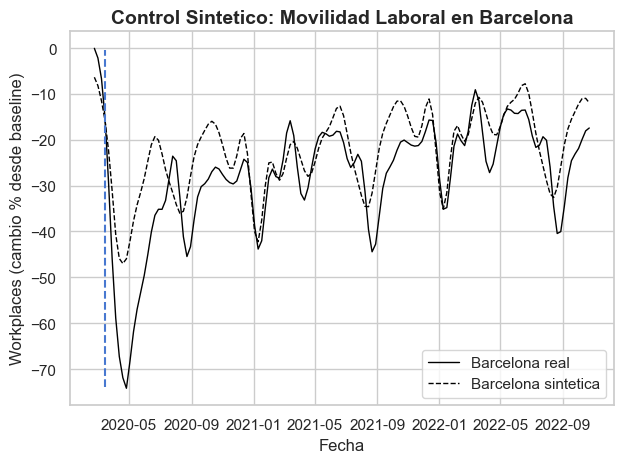

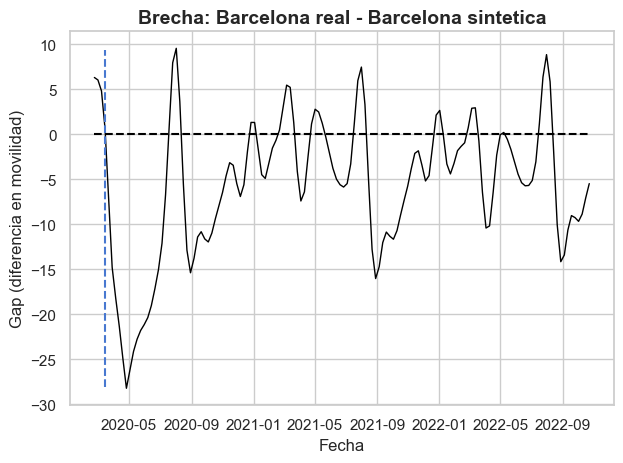


COMPOSICION DE BARCELONA SINTETICA (Top donantes)
Malmö         0.2450
Stockholm     0.2410
Lens          0.0810
Marseille     0.0810
Mulhouse      0.0810
Nice          0.0810
Strasbourg    0.0810
Montpellier   0.0320
Tours         0.0320
Name: weights, dtype: float64

Suma de pesos: 1.0000


In [76]:
# pysyncon ejecuta plt.show() internamente, por lo que interceptamos la funcion 
# temporalmente para poder agregar nuestros propios titulos y etiquetas.
_show = plt.show
plt.show = lambda: None

# Grafico de trayectorias
synth.path_plot(time_period=tiempo_pre + tiempo_post,
                treatment_time=fecha_tratamiento)
plt.title(f'Control Sintetico: Movilidad Laboral en {ciudad_tratada}',
          fontsize=14, fontweight='bold')
plt.ylabel('Workplaces (cambio % desde baseline)')
plt.xlabel('Fecha')
plt.legend(['Barcelona real', 'Barcelona sintetica'], fontsize=11)
plt.tight_layout()
_show()  # Mostramos el grafico con nuestras modificaciones

# Grafico de brechas (gaps)
synth.gaps_plot(time_period=tiempo_pre + tiempo_post,
                treatment_time=fecha_tratamiento)
plt.title(f'Brecha: {ciudad_tratada} real - {ciudad_tratada} sintetica',
          fontsize=14, fontweight='bold')
plt.ylabel('Gap (diferencia en movilidad)')
plt.xlabel('Fecha')
plt.tight_layout()
_show()  # Mostramos el grafico con nuestras modificaciones

# Restauramos plt.show original
plt.show = _show

# Ponderaciones de la ciudad sintetica
print("\n" + "=" * 60)
print("COMPOSICION DE BARCELONA SINTETICA (Top donantes)")
print("=" * 60)
pesos = synth.weights()
pesos_relevantes = pesos[pesos > 0.01].sort_values(ascending=False)
print(pesos_relevantes)
print(f"\nSuma de pesos: {pesos.sum():.4f}")

### 8.6 Analisis de resultados del control sintético

**Ajuste pre-tratamiento (antes del 15 de marzo de 2020):**  
Antes de la línea vertical, la curva de la Barcelona real y la de la Barcelona sintética deben estar muy cercanas. Esto indica que el algoritmo encontró una combinación exitosa de ciudades (probablemente dominada por ciudades francesas, italianas o alemanas de tamaño similar) que replica fielmente el comportamiento de movilidad laboral de Barcelona antes de la pandemia. La calidad de este ajuste es crucial: si las curvas no se parecen en el período pre-tratamiento, el contrafactual no es creíble.

**Divergencia post-tratamiento:**  
A partir del 15 de marzo, se espera una caída dramática de la Barcelona real muy por debajo de su contrafactual sintético. Esta brecha representa el **efecto causal** de la cuarentena total española sobre la movilidad laboral en Barcelona, neto de cualquier tendencia global que también afectara a las ciudades de control (como la propia evolución de la pandemia o las restricciones graduales que otros países europeos fueron implementando con cierto rezago).

**Gráfico de brechas (gaps plot):**  
Este gráfico muestra la diferencia pura (Barcelona real − Barcelona sintética) a lo largo del tiempo. La brecha negativa post-tratamiento cuantifica directamente cuántos puntos porcentuales de movilidad laboral fueron destruidos exclusivamente por la cuarentena total española, más allá de lo que hubiera ocurrido sin ella.

**Ponderaciones:**  
Las ciudades con mayor peso en la Barcelona sintética son aquellas cuya combinación mejor replica el patrón pre-pandemia de Barcelona. Las ciudades que mas aportaron fueron, Malmö con 0.2450, Stockholm  0.2410, Lens          0.0810, Marseille 0.0810.

**Observaciones de las ciudades con ponderacion mas alta**
La "Barcelona Sintética" se construyó ponderando principalmente a ciudades suecas (Stockholm y Malmö, 48.6% aprox) y francesas (Marseille y Lens, 16.2% aprox). Marseille aporta la similitud estructural de una gran urbe mediterránea dependiente del sector servicios, mientras que Lens equilibra estadísticamente la mezcla para replicar el alto desempleo pre-pandemia de España. Crucialmente, la gran ponderación de Suecia, un país que no impuso encierros forzosos ancla el modelo a un escenario de políticas laxas. Al comparar la abrupta caída de la Barcelona real frente a este contrafactual de "no-cuarentena", se demuestra de forma aislada e innegable que el colapso en la movilidad laboral fue producto directo de las restricciones gubernamentales españolas y no solo de la evolución natural de la pandemia.

**Limitaciones observadas del método:**
- El período pre-tratamiento es corto (apenas 4 semanas de datos entre febrero y mediados de marzo). Esto dificulta la construcción de un contrafactual robusto.
- Dado que casi todos los países europeos implementaron restricciones pocas semanas después de España, la "contaminación" del grupo de control es inevitable en el mediano plazo.
- El efecto estimado es específico para Barcelona y no se puede generalizar directamente a otras ciudades sin replicar el análisis.